In [ ]:
# ============================================================
# PARKINSON'S EEG (ds003490) — FILTERING ONLY (ALL SUBJECTS)
# CHANNEL-REDUCED VERSION (IMPORTANT CHANNELS ONLY)
#
# Keeps ONLY these EEG channels (if present):
#   Frontal:        F3, F4, Fz
#   Fronto-central: FC1, FC2, FCz
#   Central:        C3, C4, Cz
#   Parietal:       P3, P4, Pz
#
# Drops VEOG and X/Y/Z etc.
# Applies: notch (PowerLineFrequency from *_eeg.json, fallback 60 Hz)
#          band-pass 0.5–50 Hz
# Saves filtered continuous EEG as .fif in mirrored folders
# ============================================================

# ----------------------------
# 0) SETUP: Drive + Libraries
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

!pip -q install mne mne-bids

import json
from pathlib import Path
import mne


# ----------------------------
# 1) PATHS
# ----------------------------
BIDS_ROOT = Path("/content/drive/MyDrive/ds003490")
OUT_ROOT  = Path("/content/drive/MyDrive/ds003490_filtered_selected_channels")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", BIDS_ROOT.exists())
print("Output folder:", OUT_ROOT)


# ----------------------------
# 2) FIND ALL REST EEG FILES
# ----------------------------
set_files = sorted(BIDS_ROOT.rglob("*_task-Rest_eeg.set"))

print("Rest EEG .set files found:", len(set_files))
if len(set_files) == 0:
    raise FileNotFoundError("No *task-Rest_eeg.set files found. Check BIDS_ROOT path.")


# ----------------------------
# 3) HELPER: Power line frequency from sidecar JSON
# ----------------------------
def get_powerline_freq(set_path: Path, default_hz: float = 60.0) -> float:
    sidecar = set_path.with_suffix(".json")
    if sidecar.exists():
        try:
            with open(sidecar, "r") as f:
                meta = json.load(f)
            return float(meta.get("PowerLineFrequency", default_hz))
        except Exception:
            return float(default_hz)
    return float(default_hz)


# ----------------------------
# 4) CHANNEL LIST (DEDUPED)
# ----------------------------
SELECTED_CHANNELS = [
    "F3", "F4", "Fz",
    "FC1", "FC2", "FCz",
    "C3", "C4", "Cz",
    "P3", "P4", "Pz"
]

print("Selected channels:", SELECTED_CHANNELS)
print("Total selected channels:", len(SELECTED_CHANNELS))


# ----------------------------
# 5) FILTER SETTINGS
# ----------------------------
HIGH_PASS = 0.5
LOW_PASS  = 50.0
DEFAULT_NOTCH = 60.0


# ----------------------------
# 6) MAIN LOOP: LOAD → SELECT CHS → NOTCH → BANDPASS → SAVE
# ----------------------------
for i, eeg_set in enumerate(set_files, start=1):
    print(f"\n[{i}/{len(set_files)}] Processing: {eeg_set}")

    # --- Load continuous EEGLAB file
    raw = mne.io.read_raw_eeglab(eeg_set, preload=True, verbose="ERROR")

    # --- Drop accelerometer channels if present
    acc_chs = [ch for ch in raw.ch_names if ch in ["X", "Y", "Z"]]
    if acc_chs:
        raw.drop_channels(acc_chs)

    # --- Ensure EEG channels are typed correctly (fallback)
    # (We are selecting by channel name next, but this keeps consistency.)
    if len(mne.pick_types(raw.info, eeg=True)) == 0:
        raw.set_channel_types({ch: "eeg" for ch in raw.ch_names if ch != "VEOG"})

    # --- Determine which of the selected channels exist in this file
    present = [ch for ch in SELECTED_CHANNELS if ch in raw.ch_names]

    if len(present) == 0:
        print("⚠️ None of the selected channels found in this file. Skipping.")
        continue

    # --- Keep only the selected EEG channels (drops VEOG automatically if not listed)
    raw_sel = raw.copy().pick_channels(present)

    # --- Notch frequency
    notch_hz = get_powerline_freq(eeg_set, default_hz=DEFAULT_NOTCH)

    # --- Apply filters
    raw_sel.notch_filter(freqs=[notch_hz], method="spectrum_fit", verbose="ERROR")
    raw_sel.filter(l_freq=HIGH_PASS, h_freq=LOW_PASS, verbose="ERROR")

    # --- Mirror folder structure
    rel = eeg_set.relative_to(BIDS_ROOT)
    out_dir = OUT_ROOT / rel.parent
    out_dir.mkdir(parents=True, exist_ok=True)

    # --- Output filename
    out_name = eeg_set.name.replace(
        "_eeg.set",
        f"_filtered_selectedCh_{HIGH_PASS}-{LOW_PASS}Hz_notch{int(notch_hz)}.fif"
    )
    out_path = out_dir / out_name

    # --- Save filtered EEG (selected channels only)
    raw_sel.save(out_path, overwrite=True, verbose="ERROR")

    print(f"✅ Saved: {out_path.name}")
    print(f"   Channels kept ({len(raw_sel.ch_names)}): {raw_sel.ch_names}")
    print(f"   Notch: {notch_hz} Hz | Band-pass: {HIGH_PASS}-{LOW_PASS} Hz")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists: True
Output folder: /content/drive/MyDrive/ds003490_filtered_selected_channels
Rest EEG .set files found: 75
Selected channels: ['F3', 'F4', 'Fz', 'FC1', 'FC2', 'FCz', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz']
Total selected channels: 12

[1/75] Processing: /content/drive/MyDrive/ds003490/sub-001/ses-01/eeg/sub-001_ses-01_task-Rest_eeg.set
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Saved: sub-001_ses-01_task-Rest_filtered_selectedCh_0.5-50.0Hz_notch60.fif
   Channels kept (12): ['F3', 'F4', 'Fz', 'FC1', 'FC2', 'FCz', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz']
   Notch: 60.0 Hz | Band-pass: 0.5-50.0 Hz

[2/75] Processing: /content/drive/MyDrive/ds003490/sub-001/ses-02/eeg/sub-001_ses-02_task-Rest_eeg.set
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Saved: sub-001_ses-02_task-Rest_fi

Channels present (will be plotted): ['F3', 'F4', 'Fz', 'FC1', 'FC2', 'FCz', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz']


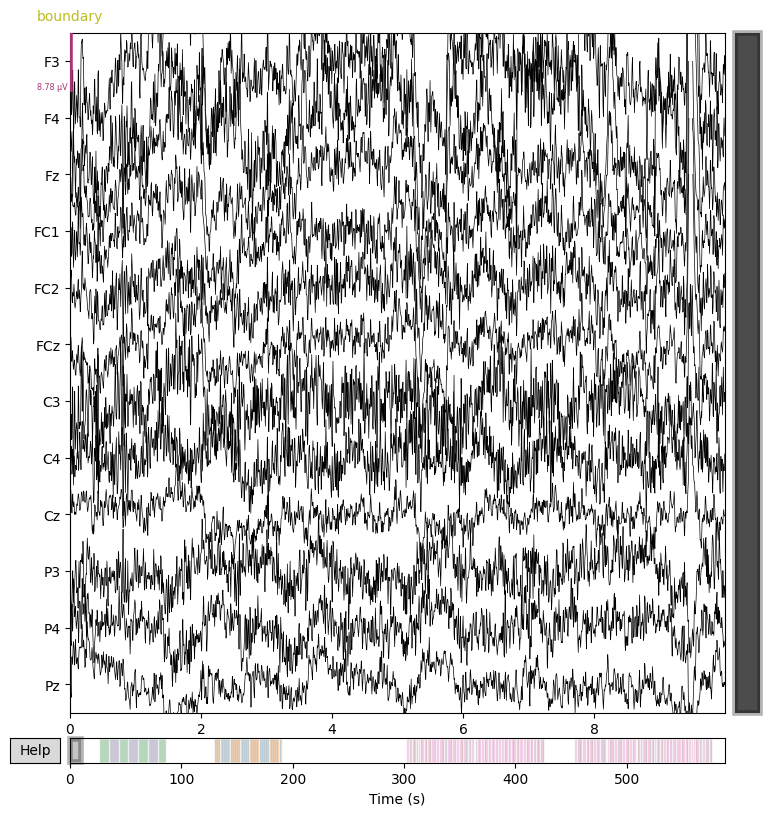

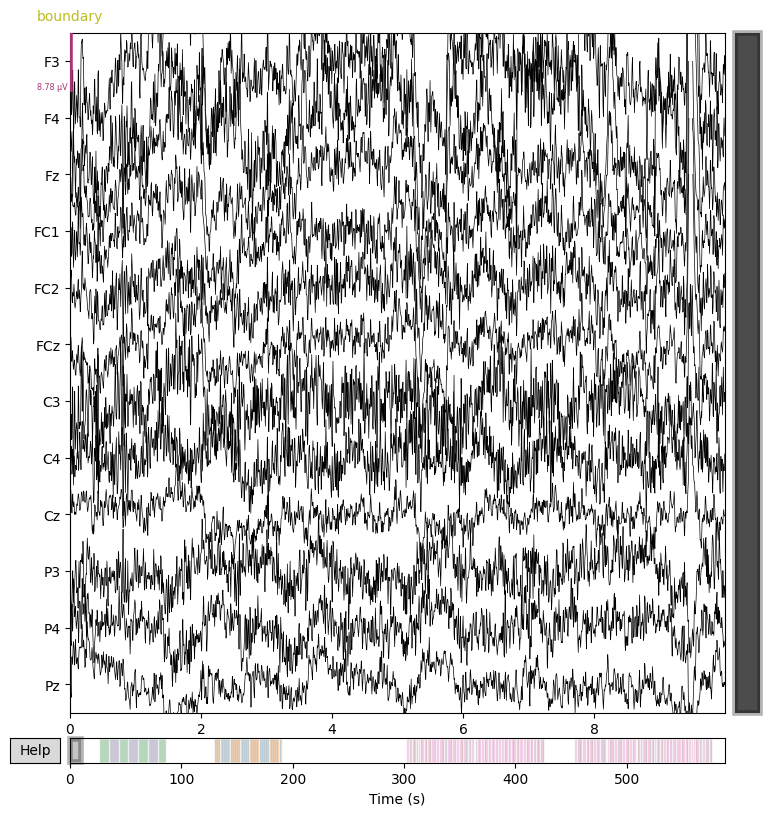

In [ ]:
# ============================================================
# VIEW SIGNALS
# Channels to show:
# F3, F4, Fz
# FC1, FC2, FCz
# C3, C4, Cz
# P3, P4, Pz
# ============================================================

import mne
from pathlib import Path

# ----------------------------
# 1) PATH: load ONE output file from your "selected channels" pipeline
# ----------------------------
fif_path = Path(
    "/content/drive/MyDrive/ds003490_filtered_selected_channels/sub-001/ses-01/eeg/sub-001_ses-01_task-Rest_filtered_selectedCh_0.5-50.0Hz_notch60.fif"
)

raw = mne.io.read_raw_fif(fif_path, preload=True, verbose="ERROR")

# ----------------------------
# 2) Channel list (deduped)
# ----------------------------
CHS = ["F3","F4","Fz","FC1","FC2","FCz","C3","C4","Cz","P3","P4","Pz"]

# Keep only channels that are actually present (safety)
present = [ch for ch in CHS if ch in raw.ch_names]
missing = [ch for ch in CHS if ch not in raw.ch_names]

print("Channels present (will be plotted):", present)
if missing:
    print("⚠️ Missing channels (not in this file):", missing)

# ----------------------------
# 3) Plot signals (stacked traces) like your screenshot
# ----------------------------
raw.plot(
    picks=present,      # ONLY these channels
    start=0,            # start time (seconds)
    duration=10,        # window length (seconds)
    n_channels=len(present),
    scalings="auto"     # auto µV scaling
)
